In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt
import os
import tensorflow_probability as tfp
tfd = tfp.distributions

tf.config.list_physical_devices('GPU')

[]

# importing data

In [4]:
df = pd.read_csv('../camels_info/camels_parameters.csv')
df

,Name,Omega_m,sigma_8,A_SN1,A_AGN1,A_SN2,A_AGN2,seed
0,LH_0,0.3090,0.9790,3.11234,1.12194,0.66850,0.53182,0
1,LH_1,0.3026,0.9394,3.42001,3.96137,1.03311,1.16070,1
2,LH_2,0.4282,0.7530,0.70613,0.37423,1.96292,0.62720,2
3,LH_3,0.1906,0.6286,1.60882,0.39887,0.86634,0.86634,3
4,LH_4,0.1382,0.6874,1.19914,0.27586,0.82188,0.91700,4
...,...,...,...,...,...,...,...,...
1092,CV_26,0.3000,0.8000,1.00000,1.00000,1.00000,1.00000,27
1093,EX_0,0.3000,0.8000,1.00000,1.00000,1.00000,1.00000,13560
1094,EX_1,0.3000,0.8000,1.00000,100.00000,1.00000,1.00000,13560
1095,EX_2,0.3000,0.8000,100.00000,1.00000,1.00000,1.00000,13560


In [5]:
df.loc[df['Name'] == "LH_0"].values[0][1:-1]

array([0.309, 0.979, 3.11234, 1.12194, 0.6685, 0.53182], dtype=object)

In [6]:
# out_dir = "../grids/CO/20230327_1-2/"
out_dir = "../grids/CO/20230403_2/"
# out_dir = "../grids/CO/20230403_2_f/"

def get_LH_files():
    fils = list(map(lambda fil: fil[:-4], \
               (filter(lambda fil: f"LH_" in fil, os.listdir(out_dir)))))
    sorter_1P_fils = lambda filname: int(filname.split('_')[-1].replace('n', '-'))
    return sorted(fils, key=sorter_1P_fils)

sim_names = get_LH_files()
sim_names[:5], sim_names[-5:], len(sim_names)

(['LH_0', 'LH_1', 'LH_2', 'LH_3', 'LH_4'],
 ['LH_995', 'LH_996', 'LH_997', 'LH_998', 'LH_999'],
 1000)

In [7]:
if "LH_603" in sim_names:
    sim_names.remove("LH_603")
sim_names[:5], sim_names[-5:], sim_names[600:605], len(sim_names)

(['LH_0', 'LH_1', 'LH_2', 'LH_3', 'LH_4'],
 ['LH_995', 'LH_996', 'LH_997', 'LH_998', 'LH_999'],
 ['LH_600', 'LH_601', 'LH_602', 'LH_604', 'LH_605'],
 999)

In [8]:
with np.load(f"{out_dir}/all.npz") as data:
    all_curves = data['all_curves']
    all_cosmologies = data['all_cosmologies']

In [9]:
num_samples = len(sim_names)
print(num_samples)
print(all_curves.shape, all_cosmologies.shape)
print(np.sum(np.isnan(all_curves[:])), np.sum(np.isnan(all_cosmologies)))

999
(999, 34, 18, 18, 18) (999, 6)
0 0


In [10]:
train_split, val_split, test_split = int(0.85*num_samples), \
            int(0.10*num_samples) + 1, int(0.05*num_samples) + 1

print(train_split, val_split, test_split, train_split+val_split+test_split)

train_x, val_x, test_x = np.split(all_curves, [train_split, train_split+val_split])
train_y, val_y, test_y = np.split(all_cosmologies, [train_split, train_split+val_split])

train_x, val_x, test_x = map(lambda arr: np.transpose(arr, axes=[0, 2, 3, 4, 1]), [train_x, val_x, test_x])

print(train_x.shape, val_x.shape, test_x.shape)
print(train_y.shape, val_y.shape, test_y.shape)

849 100 50 999
(849, 18, 18, 18, 34) (100, 18, 18, 18, 34) (50, 18, 18, 18, 34)
(849, 6) (100, 6) (50, 6)


# permutations

In [11]:
from itertools import permutations

permutations_list = list(permutations([1, 2, 3]))

train_x_new, train_y_new = np.empty((train_x.shape[0]*len(permutations_list), *train_x.shape[1:])), \
                        np.empty((train_x.shape[0]*len(permutations_list), *train_y.shape[1:]))

for ind, (i, j, k) in enumerate(permutations_list):
    print(ind, i, j, k)
    train_x_new[ind*len(train_x):(ind+1)*len(train_x)] = np.transpose(train_x, axes=[0, i, j, k, 4])
    train_y_new[ind*len(train_y):(ind+1)*len(train_y)] = train_y
    
train_x_new.shape, train_y_new.shape

0 1 2 3
1 1 3 2
2 2 1 3
3 2 3 1
4 3 1 2
5 3 2 1


((5094, 18, 18, 18, 34), (5094, 6))

In [12]:
# input_shape = (74, 74, 74, 34)
input_shape = (18, 18, 18, 34)
output_num = 6

model = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=input_shape),
    tf.keras.layers.Dense(256, activation='leaky_relu'),
  tf.keras.layers.Dense(256, activation='leaky_relu'),
  tf.keras.layers.Dense(256, activation='leaky_relu'),
  # tf.keras.layers.Conv3D(256, kernel_size=(2, 2, 2), activation='relu'),
  # tf.keras.layers.MaxPooling3D(pool_size=(2, 2, 2)),
  # tf.keras.layers.Conv3D(256, kernel_size=(2, 2, 2), activation='relu'),
  # tf.keras.layers.MaxPooling3D(pool_size=(2, 2, 2)),
  # tf.keras.layers.Conv3D(256, kernel_size=(2, 2, 2), activation='relu'),
  # tf.keras.layers.MaxPooling3D(pool_size=(2, 2, 2)),
  # tf.keras.layers.Dense(256, activation='leaky_relu'),
  # tf.keras.layers.Dense(256, activation='leaky_relu'),
  tf.keras.layers.Dense(256, activation='relu'),
  tf.keras.layers.Dense(256, activation='relu'),
  tf.keras.layers.Dense(output_num, activation='linear') # assuming 6 output parameters
])

# Compile the model
# model.compile(loss='mse', optimizer='adam')
# model.compile(loss='mae', optimizer='adam')
model.compile(loss=tf.keras.losses.LogCosh(), optimizer='adam')

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 198288)            0         
                                                                 
 dense (Dense)               (None, 256)               50761984  
                                                                 
 dense_1 (Dense)             (None, 256)               65792     
                                                                 
 dense_2 (Dense)             (None, 256)               65792     
                                                                 
 dense_3 (Dense)             (None, 256)               65792     
                                                                 
 dense_4 (Dense)             (None, 256)               65792     
                                                                 
 dense_5 (Dense)             (None, 6)                 1

In [13]:
# Train the model
history = model.fit(train_x_new, train_y_new, epochs=10, validation_data=(val_x, val_y))

Epoch 1/10
160/160 [==============================] - 15s 88ms/step - loss: 2.4556 - val_loss: 0.2481
Epoch 2/10
160/160 [==============================] - 14s 86ms/step - loss: 0.3505 - val_loss: 0.2635
Epoch 3/10
160/160 [==============================] - 14s 87ms/step - loss: 0.2824 - val_loss: 0.2984
Epoch 4/10
160/160 [==============================] - 14s 86ms/step - loss: 0.1739 - val_loss: 0.2320
Epoch 5/10
160/160 [==============================] - 14s 86ms/step - loss: 0.1194 - val_loss: 0.2181
Epoch 6/10
160/160 [==============================] - 14s 86ms/step - loss: 0.0837 - val_loss: 0.1896
Epoch 7/10
160/160 [==============================] - 14s 86ms/step - loss: 0.0514 - val_loss: 0.1721
Epoch 8/10
160/160 [==============================] - 14s 86ms/step - loss: 0.0381 - val_loss: 0.2098
Epoch 9/10
160/160 [==============================] - 14s 86ms/step - loss: 0.0353 - val_loss: 0.1759
Epoch 10/10
160/160 [==============================] - 14s 86ms/step - loss: 0.029

4/4 [==============================] - 0s 7ms/step


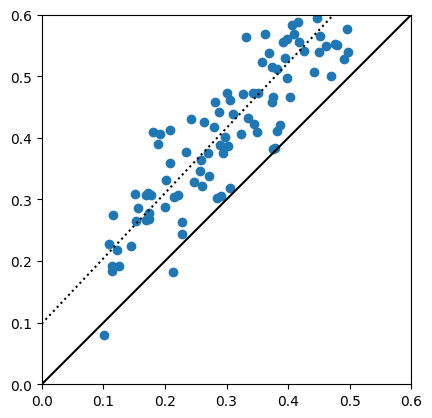

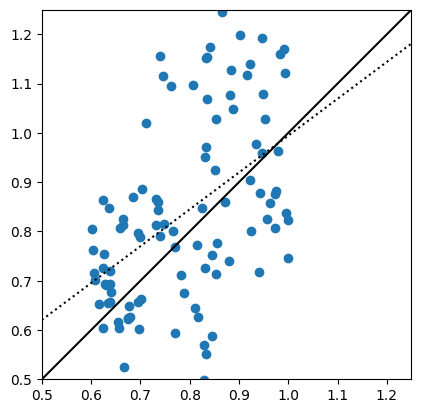

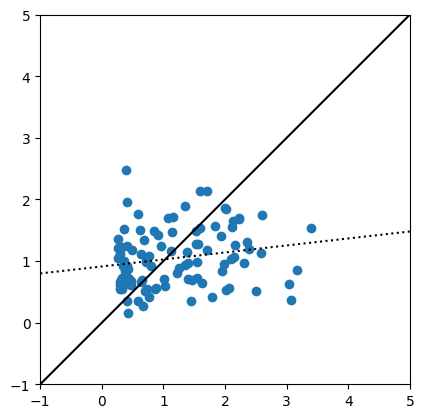

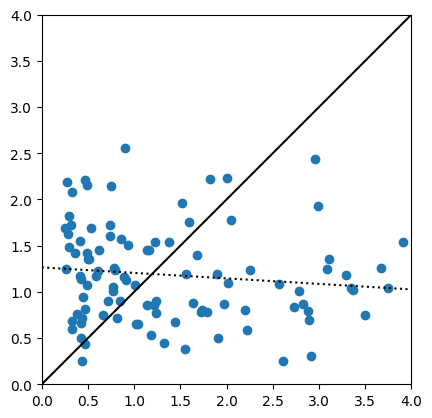

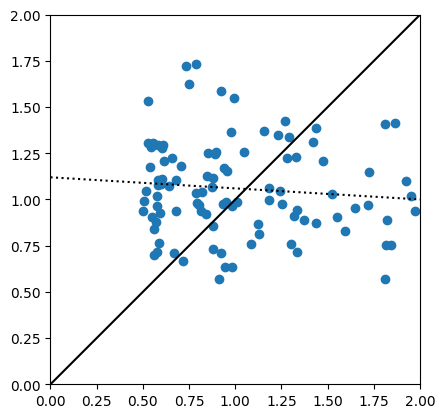

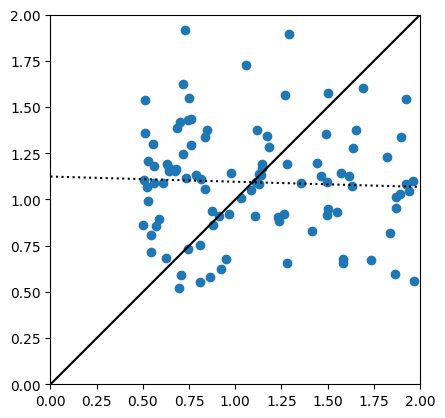

In [14]:
predictions = model.predict(val_x)
upp_lims = [0.6, 1.25, 5, 4, 2, 2]
low_lims = [0, 0.5, -1, 0, 0, 0]
for ind, (low_lim, upp_lim) in enumerate(zip(low_lims, upp_lims)):
    p = np.poly1d(np.polyfit(val_y[:, ind], predictions[:, ind], 1))
    plt.figure()
    plt.scatter(val_y[:, ind], predictions[:, ind])
    plt.plot([low_lim, upp_lim], [low_lim, upp_lim], color="black")
    plt.plot([low_lim, upp_lim], [p(low_lim), p(upp_lim)], color="black", ls=":")
    plt.xlim([low_lim, upp_lim])
    plt.ylim([low_lim, upp_lim])
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')
    plt.show()
    plt.close()

# non-symmetry

In [18]:
# Train the model
history = model.fit(train_x, train_y, epochs=5, validation_data=(val_x, val_y))

Epoch 1/5
27/27 [==============================] - 41s 1s/step - loss: 0.1798 - val_loss: 0.1502
Epoch 2/5
27/27 [==============================] - 40s 1s/step - loss: 0.1667 - val_loss: 0.1485
Epoch 3/5
27/27 [==============================] - 40s 1s/step - loss: 0.1601 - val_loss: 0.1462
Epoch 4/5
27/27 [==============================] - 40s 1s/step - loss: 0.1557 - val_loss: 0.1529
Epoch 5/5
27/27 [==============================] - 40s 1s/step - loss: 0.1459 - val_loss: 0.1504


4/4 [==============================] - 1s 90ms/step


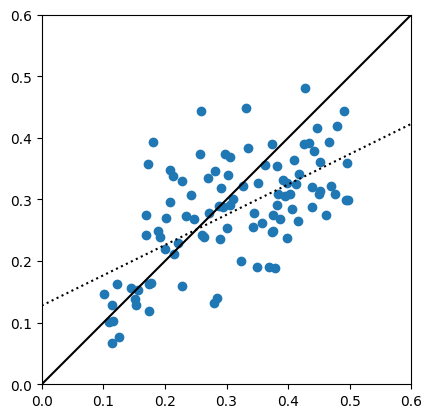

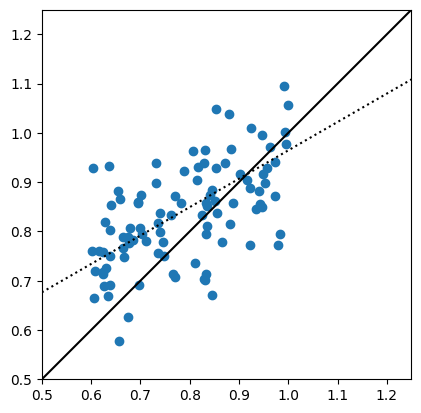

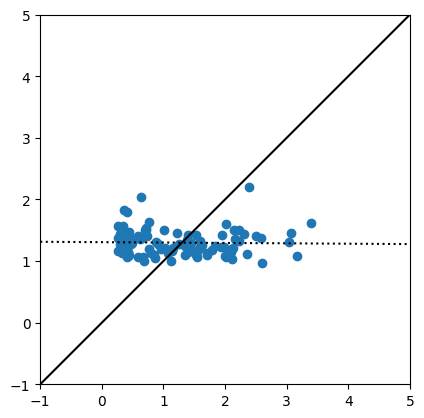

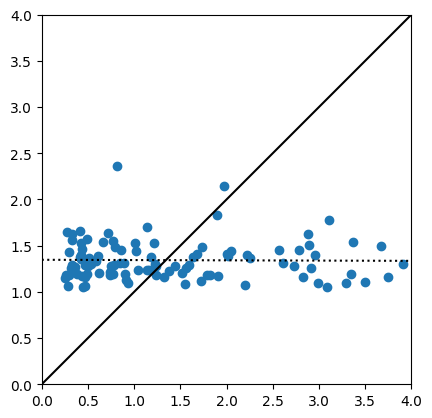

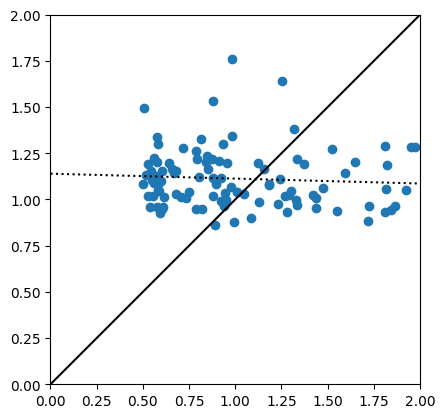

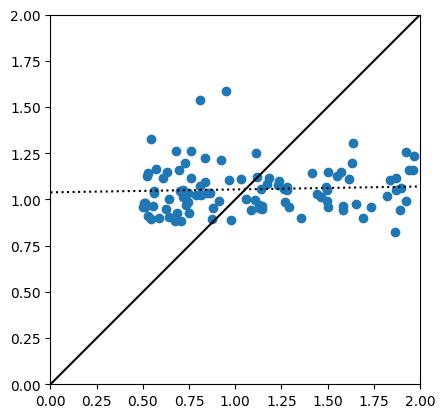

In [19]:
# non-permutation result
predictions = model.predict(val_x)
upp_lims = [0.6, 1.25, 5, 4, 2, 2]
low_lims = [0, 0.5, -1, 0, 0, 0]
for ind, (low_lim, upp_lim) in enumerate(zip(low_lims, upp_lims)):
    p = np.poly1d(np.polyfit(val_y[:, ind], predictions[:, ind], 1))
    plt.figure()
    plt.scatter(val_y[:, ind], predictions[:, ind])
    plt.plot([low_lim, upp_lim], [low_lim, upp_lim], color="black")
    plt.plot([low_lim, upp_lim], [p(low_lim), p(upp_lim)], color="black", ls=":")
    plt.xlim([low_lim, upp_lim])
    plt.ylim([low_lim, upp_lim])
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')
    plt.show()
    plt.close()